# Ejercitario: análisis de visitas al portal de una biblioteca

Este trabajo práctico utiliza **Pandas, Matplotlib y Seaborn** para analizar las visitas diarias al portal web de una biblioteca escolar entre 2022 y 2025.

El dataset está incluido en el notebook y se genera automáticamente. Ejecute primero las celdas de preparación y luego resuelva las actividades.

**Puntaje sugerido:** 40 puntos — 10 actividades de 4 puntos cada una.

Alumna: Paloma Miranda

## Preparación del entorno y creación del dataset

In [4]:
%pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 435.7 kB/s eta 0:00:01
   -------- ------------------------------ 61.4/294.9 kB 544.7 kB/s eta 0:00:01
   ------------------------------------- -- 276.5/294.9 kB 1.7 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 1.6 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\PUBLICO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [3]:
# Dataset incluido: se genera siempre con los mismos datos
rng = np.random.default_rng(2026)
fechas = pd.date_range('2022-01-01', '2025-12-31', freq='D')
n = len(fechas)
tendencia = np.linspace(80, 280, n)
estacionalidad = 38 * np.sin(2 * np.pi * fechas.dayofyear.to_numpy() / 365.25)
efecto_semana = np.where(fechas.dayofweek.to_numpy() < 5, 35, -25)
ruido = rng.normal(0, 22, n)
visitas = np.maximum(5, np.round(tendencia + estacionalidad + efecto_semana + ruido)).astype(float)

# Se agregan valores atípicos y faltantes para practicar limpieza
indices_atipicos = rng.choice(n, 14, replace=False)
visitas[indices_atipicos] *= rng.integers(3, 6, len(indices_atipicos))
indices_faltantes = rng.choice(np.setdiff1d(np.arange(n), indices_atipicos), 12, replace=False)
visitas[indices_faltantes] = np.nan

df = pd.DataFrame({'fecha': fechas, 'visitas': visitas})
df.head()

,fecha,visitas
0,2022-01-01,38.0
1,2022-01-02,62.0
2,2022-01-03,76.0
3,2022-01-04,149.0
4,2022-01-05,133.0


## Actividad 1 — Inspección inicial (4 puntos)
Muestre las primeras 10 y las últimas 5 filas. Luego indique cuántas filas y columnas posee el dataset.

In [6]:
print("Primeras 10 filas:")
display(df.head(10))

print("\nÚltimas 5 filas:")
display(df.tail(5))

filas, columnas = df.shape

print("\nCantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

Primeras 10 filas:


,fecha,visitas
0,2022-01-01,38.0
1,2022-01-02,62.0
2,2022-01-03,76.0
3,2022-01-04,149.0
4,2022-01-05,133.0
5,2022-01-06,113.0
6,2022-01-07,114.0
7,2022-01-08,68.0
8,2022-01-09,56.0
9,2022-01-10,118.0



Últimas 5 filas:


,fecha,visitas
1456,2025-12-27,260.0
1457,2025-12-28,218.0
1458,2025-12-29,296.0
1459,2025-12-30,351.0
1460,2025-12-31,335.0



Cantidad de filas: 1461
Cantidad de columnas: 2


## Actividad 2 — Tipos y calidad de datos (4 puntos)
Utilice `info()` y verifique el tipo de cada columna. Calcule cuántos valores faltantes existen por columna.

In [7]:
# Informacion general del dataset
df.info()

# Mostrar el tipo de dato de cada columna
print("\nTipos de datos:")
for columna, tipo in df.dtypes.items():
    print(f"{columna}: {tipo}")

# Contar valores faltantes por columna
print("\nValores faltantes:")
faltantes = df.isnull().sum()
print(faltantes)

<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   fecha    1461 non-null   datetime64[us]
 1   visitas  1449 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 23.0 KB

Tipos de datos:
fecha: datetime64[us]
visitas: float64

Valores faltantes:
fecha       0
visitas    12
dtype: int64


## Actividad 3 — Estadística descriptiva (4 puntos)
Obtenga las estadísticas descriptivas de `visitas`. Responda: ¿cuál es la media, la mediana, el mínimo y el máximo?

> Pista: combine `describe()` con `median()`.

In [9]:
# Estadísticas descriptivas de la columna visitas
estadisticas = df["visitas"].describe()

print(estadisticas)

# Obtener valores específicos
media = estadisticas["mean"]
mediana = df["visitas"].median()
minimo = estadisticas["min"]
maximo = estadisticas["max"]

print("\nMedia:", media)
print("Mediana:", mediana)
print("Mínimo:", minimo)
print("Máximo:", maximo)

count    1449.000000
mean      201.999310
std        84.245871
min         8.000000
25%       149.000000
50%       197.000000
75%       251.000000
max      1004.000000
Name: visitas, dtype: float64

Media: 201.9993098688751
Mediana: 197.0
Mínimo: 8.0
Máximo: 1004.0


## Actividad 4 — Tratamiento de valores faltantes (4 puntos)
Cree un nuevo DataFrame llamado `df_limpio` eliminando las filas con visitas faltantes. Compruebe que ya no existan valores nulos e indique cuántas filas se eliminaron. No modifique `df`.

In [15]:
# Crear un nuevo DataFrame eliminando valores faltantes de visitas
df_limpio = df.dropna(subset=['visitas']).copy()

#Comprobar valores nulos
print("Valores nulos en df_limpio:")
print(df_limpio.isna().sum())

#Cantidad de filas eliminadas 
filas_eliminadas = len(df) - len(df_limpio)
print("Filas eliminadas: ",filas_eliminadas)

Valores nulos en df_limpio:
fecha      0
visitas    0
dtype: int64
Filas eliminadas:  12


## Actividad 5 — Filtrado por percentiles (4 puntos)
A partir de `df_limpio`, elimine los días ubicados en el 2,5 % inferior y en el 2,5 % superior de visitas. Guarde el resultado en `df_filtrado` e indique cuántas filas quedaron.

> Pista: calcule los cuantiles `0.025` y `0.975`.

In [12]:
# Calcular los límites de los percentiles
df_limpio = df.dropna(subset=['visitas']).copy()
limite_inferior = df_limpio["visitas"].quantile(0.025)
limite_superior = df_limpio["visitas"].quantile(0.975)

# Mantener únicamente los valores dentro de esos límites
df_filtrado = df_limpio[
    (df_limpio["visitas"] >= limite_inferior) &
    (df_limpio["visitas"] <= limite_superior)
]

# Mostrar la cantidad de filas resultantes
print("Filas restantes:", len(df_filtrado))

Filas restantes: 1376


## Actividad 6 — Gráfico de línea (4 puntos)
Realice un gráfico de línea con `df_filtrado`:

- Tamaño `(12, 5)`.
- Título: **Visitas diarias al portal de la biblioteca (2022–2025)**.
- Eje X: **Fecha**.
- Eje Y: **Cantidad de visitas**.
- Línea de color verde oscuro.

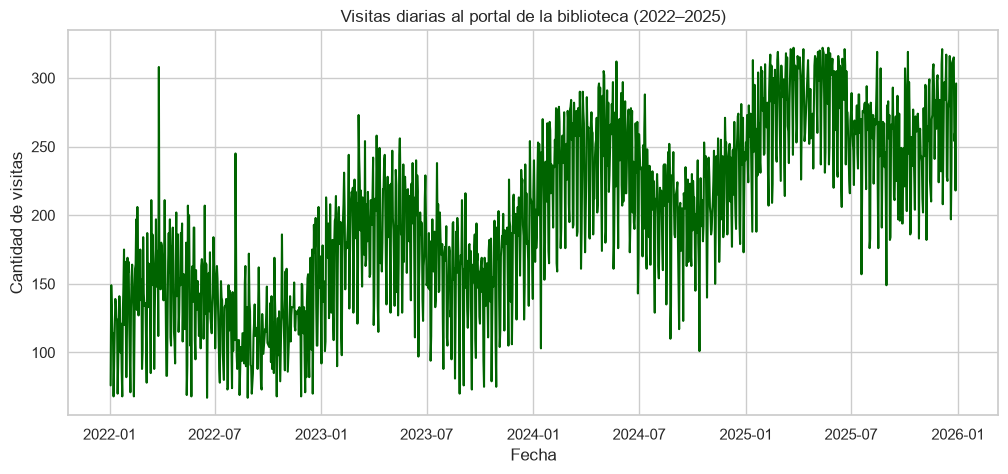

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_filtrado["fecha"],
    df_filtrado["visitas"],
    color="darkgreen"
)

plt.title("Visitas diarias al portal de la biblioteca (2022–2025)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de visitas")

plt.show()

## Actividad 7 — Distribución de visitas (4 puntos)
Construya un histograma de `visitas` usando `df_filtrado`. Agregue una curva KDE, 25 intervalos, título y etiquetas claras. Explique brevemente qué rango concentra la mayor cantidad de días.

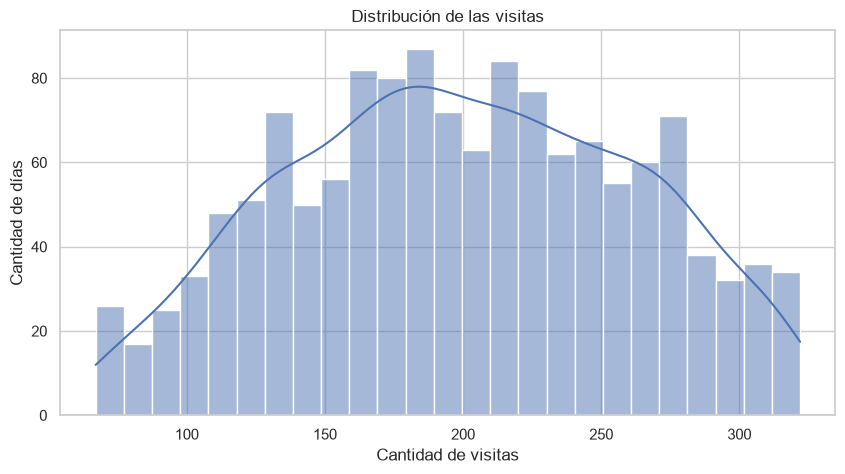

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_filtrado,
    x="visitas",
    bins=25,
    kde=True
)

plt.title("Distribución de las visitas")
plt.xlabel("Cantidad de visitas")
plt.ylabel("Cantidad de días")

plt.show()

La mayor cantidad de dias se concentra alrededor de la zona central de la distribucion , es decir cerca del valor tipivo de visitas diarias 

## Actividad 8 — Columnas temporales y resumen anual (4 puntos)
Agregue a `df_filtrado` las columnas `año`, `mes` y `dia_semana`. Después, agrupe por año y calcule la suma y el promedio de visitas. Muestre el resumen resultante.

In [15]:
# Crear las columnas relacionadas con la fecha
df_filtrado["año"] = df_filtrado["fecha"].dt.year
df_filtrado["mes"] = df_filtrado["fecha"].dt.month
df_filtrado["dia_semana"] = df_filtrado["fecha"].dt.dayofweek

# Resumen anual de visitas
resumen_anual = df_filtrado.groupby("año")["visitas"].agg(
    total="sum",
    promedio="mean"
)

print(resumen_anual)

        total    promedio
año                      
2022  43149.0  132.766154
2023  62638.0  173.512465
2024  79833.0  222.997207
2025  88158.0  265.536145


## Actividad 9 — Comparación mensual por año (4 puntos)
Calcule el promedio de visitas por `año` y `mes`. Represente el resultado en un gráfico de barras:

- Eje X: año.
- Eje Y: promedio de visitas.
- Color (`hue`): mes.
- Leyenda titulada **Mes**.
- Etiquetas del eje X giradas 45°.

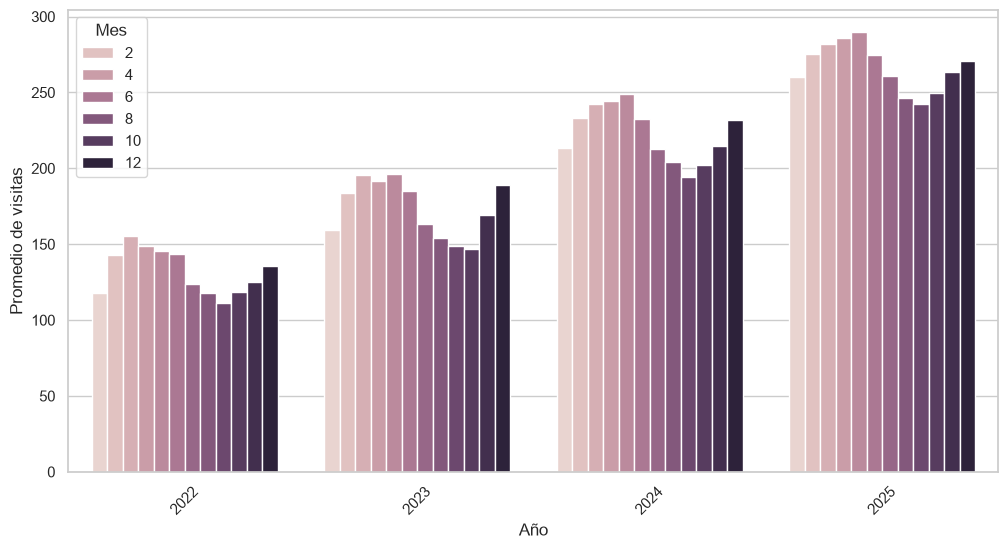

In [16]:
# Promedio de visitas agrupado por año y mes
promedio_mensual = (
    df_filtrado.groupby(["año", "mes"], as_index=False)["visitas"]
    .mean()
)

# Crear gráfico de barras
plt.figure(figsize=(12, 6))

sns.barplot(
    data=promedio_mensual,
    x="año",
    y="visitas",
    hue="mes"
)

plt.xlabel("Año")
plt.ylabel("Promedio de visitas")
plt.xticks(rotation=45)
plt.legend(title="Mes")

plt.show()

## Actividad 10 — Diagramas de caja e interpretación (4 puntos)
Cree dos diagramas de caja adyacentes mediante `subplots`:

1. Visitas por año.
2. Visitas por mes.

Use un tamaño total de `(14, 6)`, títulos y etiquetas. Finalmente, escriba dos conclusiones basadas en los gráficos.

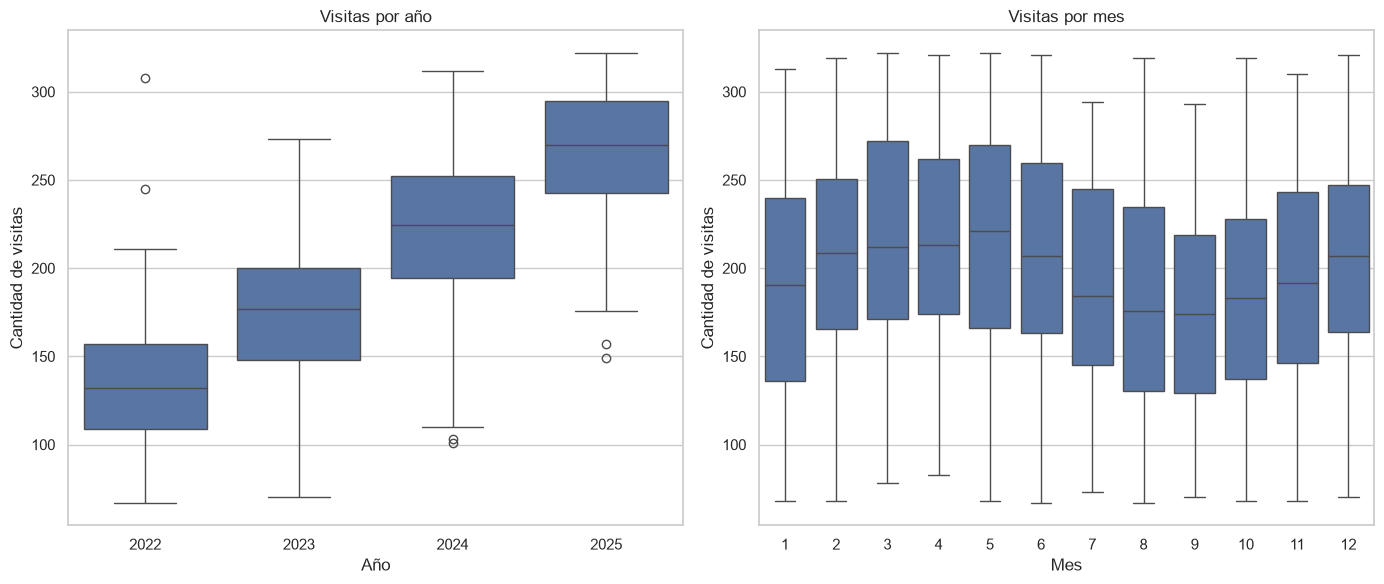

In [17]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 6))

# Diagrama de caja por año
sns.boxplot(
    data=df_filtrado,
    x="año",
    y="visitas",
    ax=ejes[0]
)

ejes[0].set_title("Visitas por año")
ejes[0].set_xlabel("Año")
ejes[0].set_ylabel("Cantidad de visitas")

# Diagrama de caja por mes
sns.boxplot(
    data=df_filtrado,
    x="mes",
    y="visitas",
    ax=ejes[1]
)

ejes[1].set_title("Visitas por mes")
ejes[1].set_xlabel("Mes")
ejes[1].set_ylabel("Cantidad de visitas")

plt.tight_layout()
plt.show()

## Conclusiones del estudiante
Redacte entre 5 y 8 líneas explicando los principales patrones identificados, la evolución de las visitas y cualquier diferencia observada entre años o meses.

El análisis muestra que las visitas presentan una tendencia creciente a lo largo de los años, pasando de valores más bajos en 2022 a valores mayores en 2025.
También se observa una variación considerable en la cantidad de visitas dentro de cada año.
Los diagramas de caja permiten identificar diferencias en las medianas y en la dispersión de las visitas entre los distintos años.
Por meses, se observa un comportamiento estacional, ya que algunos meses presentan niveles de visitas superiores a otros.
Las visitas también muestran diferencias entre períodos laborales y fines de semana, debido al efecto semanal incorporado en los datos.
En general, la evolución indica un crecimiento sostenido de las visitas acompañado de variaciones estacionales durante el año.
Finalmente, los valores atípicos y faltantes tratados durante la limpieza permitieron obtener un conjunto de datos más adecuado para el análisis.

